# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **The purpose of this Notebook**: This notebook handles ...
* **Datasets**: [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) and [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/)
    * Sleep Cassette (SC) - the study on healthy people;
    * Sleep Telemetry (ST) - sleep study in people with difficulty falling asleep. This study was designed to look at the effects of temazepam, a drug with hypnotic effects;
    * UCDDB - patients diagnosed with apnea, who do not suffer from cardiological diseases or autonomic dysfunctions and are not taking medication at the time of registration.
* **Input**:
  * class_distribution.csv
  * results.zip - a compressed archive containing the layered and prepared dataset for training (train, test, val)
    * each file in these folders represents a *processed sleep window* (epoch)
* **Output:**
  * `model_bilstm_baseline.pt`
  * `model_crnn.pt`
  * `model_resnet.pt`

# Imports

In [4]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, BatchNormalization, Flatten, Dense, Dropout, Input, GlobalAveragePooling1D, Add, Activation, SeparableConv1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from scipy.signal import medfilt
from tensorflow.keras import layers, models
import keras.ops as ops

In [2]:
import utils

In [3]:
base_path = 'process_dataset/'
train_path = base_path + 'train'
val_path = base_path + 'val'

In [ ]:
def viterbi_decode(proba_seq, transition_matrix):
    T, K = proba_seq.shape
    log_A = np.log(transition_matrix + 1e-12)
    log_B = np.log(proba_seq + 1e-12)

    log_pi = np.log(np.ones(K) / K)

    dp = np.zeros((T, K))
    ptr = np.zeros((T, K), dtype=int)

    dp[0] = log_pi + log_B[0]

    # t >= 1
    for t in range(1, T):
        for k in range(K):
            scores = dp[t - 1] + log_A[:, k]
            ptr[t, k] = np.argmax(scores)
            dp[t, k] = scores[ptr[t, k]] + log_B[t, k]

    best_path = np.zeros(T, dtype=int)
    best_path[-1] = np.argmax(dp[-1])
    for t in range(T - 2, -1, -1):
        best_path[t] = ptr[t + 1, best_path[t + 1]]

    return best_path

# Dataset

In [7]:
df_weights = pd.read_csv(base_path + 'class_distribution_train.csv')
class_weights = dict(zip(df_weights['Class_ID'], df_weights['Weight']))
print("Class weights are:", class_weights)
total_samples = df_weights['Count'].sum()
batch_size = 32
calculated_steps = total_samples // batch_size

print(f"Total number of samples: {total_samples}")
print(f"Steps per train: {calculated_steps}")

Class weights are: {0: 0.944, 1: 1.7783, 2: 0.5232, 3: 1.445, 4: 1.2905}
Total number of samples: 228213
Steps per train: 7131


# Models

In [8]:
from tensorflow.keras import layers, models

def tcn_block(x, filters, kernel_size, dilation):
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, padding='causal',
                      dilation_rate=dilation)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, kernel_size, padding='causal',
                      dilation_rate=dilation)(x)
    x = layers.BatchNormalization()(x)

    # Residual connection
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_tcn_feature_extractor(input_shape, embedding_dim=128):
    inputs = layers.Input(shape=input_shape)

    x = tcn_block(inputs, 32, 7, dilation=1)
    x = tcn_block(x, 64, 7, dilation=2)
    x = tcn_block(x, 128, 7, dilation=4)
    x = tcn_block(x, 256, 7, dilation=8)

    x = layers.GlobalAveragePooling1D()(x)
    features = layers.Dense(embedding_dim, activation=None)(x)

    return models.Model(inputs, features)

def extract_features_labels(generator, feature_model):
    X_feats_list = []
    y_list = []

    for idx in range(len(generator)):
        X_batch, y_batch = generator[idx]
        feats = feature_model.predict(X_batch, verbose=0)

        X_feats_list.append(feats)
        y_list.append(np.argmax(y_batch, axis=1))

    X_feats = np.concatenate(X_feats_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    return X_feats, y

feature_model = build_tcn_feature_extractor((4500, 2))

X_train_feats, y_train_int = extract_features_labels(train_gen, feature_model)
X_val_feats, y_val_int = extract_features_labels(val_gen, feature_model)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[46]	valid_0's multi_logloss: 0.881367
Accuracy 0.6624

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.65      0.81      0.72     10299
          N1       0.35      0.12      0.17      6882
          N2       0.68      0.81      0.74     20783
          N3       0.76      0.71      0.73      6474
         REM       0.66      0.50      0.57      7574

    accuracy                           0.66     52012
   macro avg       0.62      0.59      0.59     52012
weighted avg       0.63      0.66      0.63     52012



/home/ubuntu/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


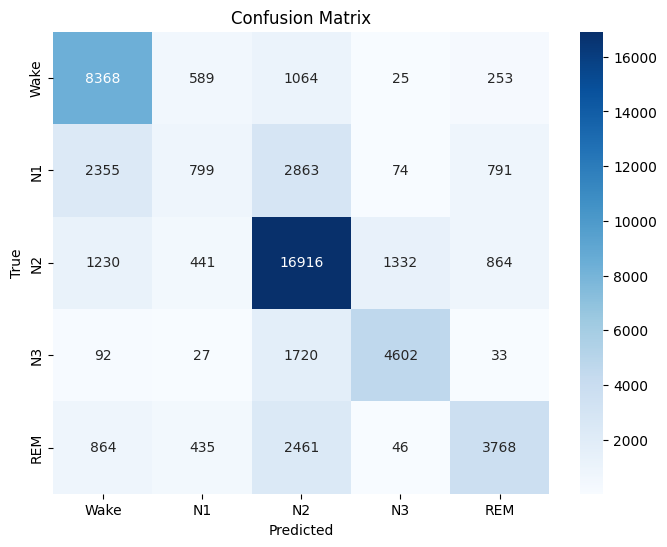

Cohen's Kappa: 0.5326


In [13]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=5,
    learning_rate=0.08,
    n_estimators=400,
    max_depth=10,
    num_leaves=125,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    min_child_samples=20,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    subsample=0.8,
    subsample_freq=3,
)

from lightgbm import early_stopping

lgb_model.fit(
    X_train_feats, y_train_int,
    eval_set=[(X_val_feats, y_val_int)],
    eval_metric="multi_logloss",
    callbacks=[early_stopping(100)]
)

y_val_pred = lgb_model.predict_proba(X_val_feats)
y_val_pred_classes = y_val_pred.argmax(axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_val_pred_classes)

In [8]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=False,
    window_size=1,
    use_lag_lead=False,
    downsample=False,
    target_length=3000,
    sampling_rate=50,
    lag_seconds=0.0
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=False,
    window_size=1,
    use_lag_lead=False,
    downsample=False,
    target_length=3000,
    sampling_rate=50,
    lag_seconds=0.0
)

y_val_true = []
for i in range(len(val_gen)):
    _, y_batch = val_gen[i]
    y_val_true.extend(np.argmax(y_batch, axis=1))

y_val_true = np.array(y_val_true)

Epoch 1/50

Epoch 1: val_loss improved from None to 1.65149, saving model to model_tinysleepnet.keras

Epoch 1: finished saving model to model_tinysleepnet.keras
259/259 - 211s - 813ms/step - accuracy: 0.4472 - loss: 1.2708 - val_accuracy: 0.2079 - val_loss: 1.6515
Epoch 2/50

Epoch 2: val_loss improved from 1.65149 to 1.35532, saving model to model_tinysleepnet.keras

Epoch 2: finished saving model to model_tinysleepnet.keras
259/259 - 193s - 743ms/step - accuracy: 0.5934 - loss: 1.0359 - val_accuracy: 0.4332 - val_loss: 1.3553
Epoch 3/50

Epoch 3: val_loss did not improve from 1.35532
259/259 - 194s - 751ms/step - accuracy: 0.6293 - loss: 0.9477 - val_accuracy: 0.5269 - val_loss: 1.4127
Epoch 4/50

Epoch 4: val_loss did not improve from 1.35532
259/259 - 198s - 766ms/step - accuracy: 0.6412 - loss: 0.9157 - val_accuracy: 0.4431 - val_loss: 1.9627
Epoch 5/50

Epoch 5: val_loss improved from 1.35532 to 1.18846, saving model to model_tinysleepnet.keras

Epoch 5: finished saving model to

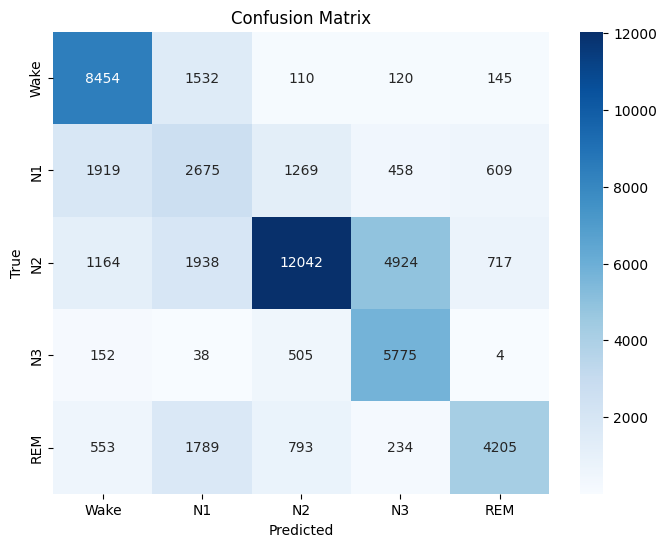

Cohen's Kappa: 0.5316


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras.ops as ops

def tiny_block(x, filters, kernel_size=11, pool_size=2, dropout=0.2):
    x = layers.SeparableConv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=pool_size)(x)
    x = layers.Dropout(dropout)(x)
    return x

def temporal_attention(x):
    score = layers.Dense(1)(x)                 # (batch, T, 1)
    weights = layers.Softmax(axis=1)(score)    # (batch, T, 1)
    context = ops.sum(x * weights, axis=1)     # (batch, F)
    return context

num_classes = 5

inputs = layers.Input(shape=(3000, 2))

# CNN depthwise blocks
x = tiny_block(inputs, 32, kernel_size=11, pool_size=2, dropout=0.1)   # 4500 → 2250
x = tiny_block(x,      64, kernel_size=11, pool_size=2, dropout=0.1)   # 2250 → 1125
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 1125 → 562
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 562 → 281

# GRU on top of features
x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)

# Attention
x = temporal_attention(x)  # (batch, 256)

# Classificator
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_tiny = models.Model(inputs, outputs)

model_tiny.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model_tiny.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[es],
    verbose=2
)

y_pred_proba = model_tiny.predict(val_gen)
y_val_pred = np.argmax(y_pred_proba, axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_val_pred)

Epoch 1/50

Epoch 1: val_loss improved from None to 3.58823, saving model to sleeptransformer_best.keras

Epoch 1: finished saving model to sleeptransformer_best.keras
259/259 - 915s - 4s/step - accuracy: 0.4829 - loss: 1.2159 - val_accuracy: 0.1650 - val_loss: 3.5882
Epoch 2/50

Epoch 2: val_loss improved from 3.58823 to 1.95072, saving model to sleeptransformer_best.keras

Epoch 2: finished saving model to sleeptransformer_best.keras
259/259 - 936s - 4s/step - accuracy: 0.5974 - loss: 1.0041 - val_accuracy: 0.3413 - val_loss: 1.9507
Epoch 3/50

Epoch 3: val_loss improved from 1.95072 to 1.22619, saving model to sleeptransformer_best.keras

Epoch 3: finished saving model to sleeptransformer_best.keras
259/259 - 940s - 4s/step - accuracy: 0.6347 - loss: 0.9392 - val_accuracy: 0.5465 - val_loss: 1.2262
Epoch 4/50

Epoch 4: val_loss did not improve from 1.22619
259/259 - 913s - 4s/step - accuracy: 0.6470 - loss: 0.9037 - val_accuracy: 0.5043 - val_loss: 1.4288
Epoch 5/50

Epoch 5: val_lo

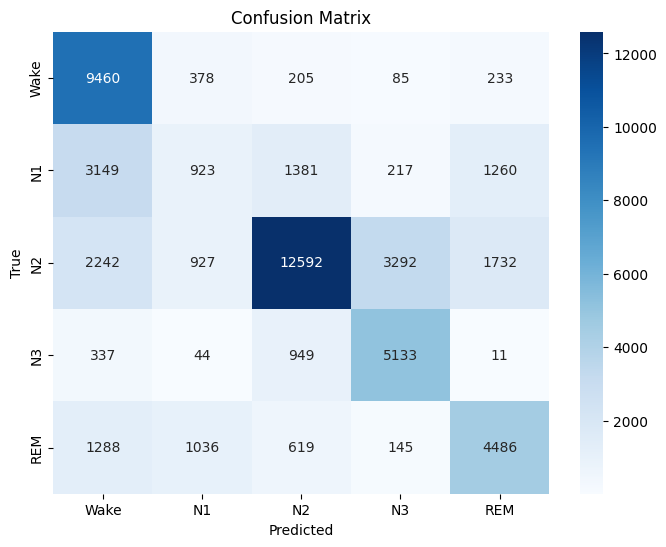

Cohen's Kappa: 0.5106


In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras.ops as ops
import numpy as np

def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)
    angles = pos * angle_rates
    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.constant(pe, dtype=tf.float32)

def transformer_block(x, num_heads=4, key_dim=64, ff_dim=256, dropout=0.1):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(x.shape[-1])(ff)
    ff = layers.Dropout(dropout)(ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    return x

seq_len = 3000
n_channels = 2
d_model = 64
num_heads = 4
ff_dim = 256
num_layers = 2
num_classes = 5

inputs = layers.Input(shape=(seq_len, n_channels))

# CNN front-end
x = layers.Conv1D(32, 11, padding="same", activation="relu")(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)   # 3000 → 1500

x = layers.Conv1D(64, 11, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)   # 1500 → 750

x = layers.Conv1D(64, 11, padding="same", activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling1D(2)(x)   # 750 → 375

# Proiecție în d_model
x = layers.Dense(d_model)(x)    # (batch, 375, 64)

# Positional encoding
pe = positional_encoding(375, d_model)
x = x + pe[None, :ops.shape(x)[1], :]

# Transformer encoder stack
for _ in range(num_layers):
    x = transformer_block(x, num_heads=num_heads, key_dim=d_model//num_heads, ff_dim=ff_dim)

# Global pooling
x = layers.GlobalAveragePooling1D()(x)

# Classifier
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_st = models.Model(inputs, outputs)

model_st.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

ckpt = tf.keras.callbacks.ModelCheckpoint(
    "sleeptransformer_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model_st.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[es, ckpt],
    verbose=2
)

y_pred_proba = model_st.predict(val_gen)
y_val_pred = np.argmax(y_pred_proba, axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_val_pred)

Epoch 1/50

Epoch 1: val_loss improved from None to 2.18934, saving model to model_tinysleepnet.keras

Epoch 1: finished saving model to model_tinysleepnet.keras
259/259 - 204s - 788ms/step - accuracy: 0.4589 - loss: 1.7384 - val_accuracy: 0.1242 - val_loss: 2.1893
Epoch 2/50

Epoch 2: val_loss improved from 2.18934 to 2.07279, saving model to model_tinysleepnet.keras

Epoch 2: finished saving model to model_tinysleepnet.keras
259/259 - 193s - 746ms/step - accuracy: 0.5521 - loss: 1.5119 - val_accuracy: 0.3189 - val_loss: 2.0728
Epoch 3/50

Epoch 3: val_loss improved from 2.07279 to 0.98680, saving model to model_tinysleepnet.keras

Epoch 3: finished saving model to model_tinysleepnet.keras
259/259 - 195s - 754ms/step - accuracy: 0.5969 - loss: 1.4277 - val_accuracy: 0.5889 - val_loss: 0.9868
Epoch 4/50

Epoch 4: val_loss did not improve from 0.98680
259/259 - 198s - 764ms/step - accuracy: 0.6204 - loss: 1.3807 - val_accuracy: 0.5644 - val_loss: 1.1092
Epoch 5/50

Epoch 5: val_loss did

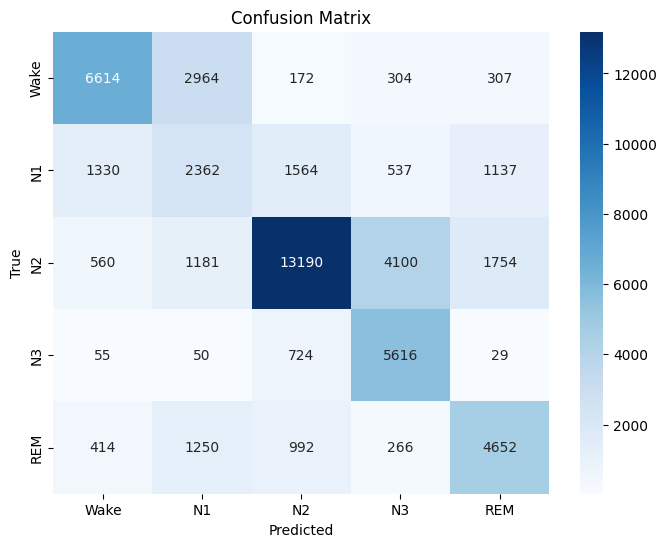

Cohen's Kappa: 0.5099


In [24]:
class_weights = {
    0: 1.0,    # Wake
    1: 2.5,    # N1 (foarte greu)
    2: 1.0,    # N2
    3: 1.2,    # N3
    4: 2.0     # REM
}

import tensorflow as tf
from tensorflow.keras import layers, models
import keras.ops as ops

def tiny_block(x, filters, kernel_size=11, pool_size=2, dropout=0.2):
    x = layers.SeparableConv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=pool_size)(x)
    x = layers.Dropout(dropout)(x)
    return x

def temporal_attention(x):
    score = layers.Dense(1)(x)                 # (batch, T, 1)
    weights = layers.Softmax(axis=1)(score)    # (batch, T, 1)
    context = ops.sum(x * weights, axis=1)     # (batch, F)
    return context

num_classes = 5

inputs = layers.Input(shape=(3000, 2))

# CNN depthwise blocks (TinySleepNet-like)
x = tiny_block(inputs, 32, kernel_size=11, pool_size=2, dropout=0.1)   # 4500 → 2250
x = tiny_block(x,      64, kernel_size=11, pool_size=2, dropout=0.1)   # 2250 → 1125
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 1125 → 562
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 562 → 281

# GRU peste features
x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)

# Attention peste secvență
x = temporal_attention(x)  # (batch, 256)

# Clasificator final
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_tiny = models.Model(inputs, outputs)

model_tiny.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

ckpt = tf.keras.callbacks.ModelCheckpoint(
    "model_tinysleepnet.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history = model_tiny.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[es, ckpt],
    verbose=2
)

y_pred_proba = model_tiny.predict(val_gen)
y_val_pred = np.argmax(y_pred_proba, axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_val_pred)

## TinySleepNet‑Lite (Focal Loss + alpha per class)

In [ ]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=True,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5
)

y_val_true = []
for i in range(len(val_gen)):
    _, y_batch = val_gen[i]
    y_val_true.extend(np.argmax(y_batch, axis=1))

y_val_true = np.array(y_val_true)

E0000 00:00:1781169396.863150 1009850 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50


I0000 00:00:1781169397.248486 1009850 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.



Epoch 1: val_loss improved from None to 1.92707, saving model to model_tinysleepnet.keras

Epoch 1: finished saving model to model_tinysleepnet.keras
259/259 - 274s - 1s/step - accuracy: 0.4638 - loss: 1.1038 - val_accuracy: 0.1242 - val_loss: 1.9271
Epoch 2/50

Epoch 2: val_loss did not improve from 1.92707
259/259 - 249s - 961ms/step - accuracy: 0.5773 - loss: 0.8466 - val_accuracy: 0.3189 - val_loss: 1.9995
Epoch 3/50

Epoch 3: val_loss improved from 1.92707 to 1.32889, saving model to model_tinysleepnet.keras

Epoch 3: finished saving model to model_tinysleepnet.keras
259/259 - 240s - 928ms/step - accuracy: 0.6143 - loss: 0.7861 - val_accuracy: 0.5148 - val_loss: 1.3289
Epoch 4/50

Epoch 4: val_loss improved from 1.32889 to 1.09415, saving model to model_tinysleepnet.keras

Epoch 4: finished saving model to model_tinysleepnet.keras
259/259 - 237s - 915ms/step - accuracy: 0.6336 - loss: 0.7353 - val_accuracy: 0.5597 - val_loss: 1.0941
Epoch 5/50

Epoch 5: val_loss did not improve f

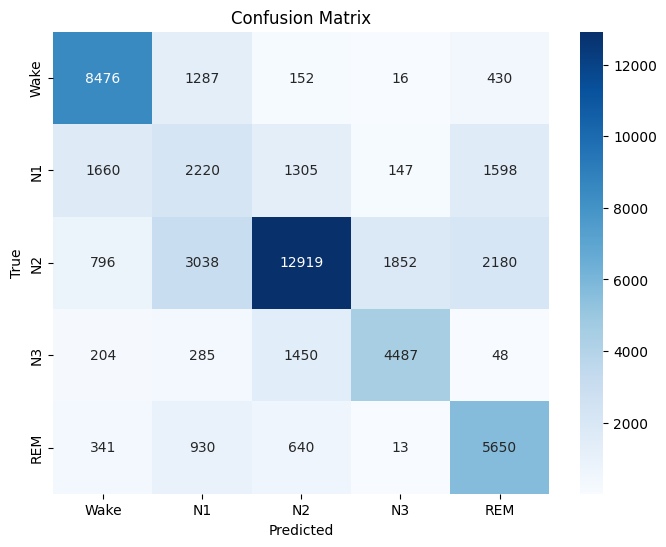

Cohen's Kappa: 0.5407


In [9]:
def tiny_block(x, filters, kernel_size=11, pool_size=2, dropout=0.2):
    x = layers.SeparableConv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=pool_size)(x)
    x = layers.Dropout(dropout)(x)
    return x

def temporal_attention(x):
    score = layers.Dense(1)(x)
    weights = layers.Softmax(axis=1)(score)
    context = ops.sum(x * weights, axis=1)
    return context

num_classes = 5

inputs = layers.Input(shape=(3000, 2))

x = tiny_block(inputs, 32, kernel_size=11, pool_size=2, dropout=0.1)   # 4500 → 2250
x = tiny_block(x, 64, kernel_size=11, pool_size=2, dropout=0.1)   # 2250 → 1125
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 1125 → 562
x = tiny_block(x,     128, kernel_size=11, pool_size=2, dropout=0.1)   # 562 → 281

x = layers.Bidirectional(layers.GRU(128, return_sequences=True))(x)
x = layers.Dropout(0.3)(x)

x = temporal_attention(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_tiny = models.Model(inputs, outputs)

alpha = [1.0, 3.0, 1.0, 1.2, 2.5]

model_tiny.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=utils.categorical_focal_loss(gamma=2.0, alpha=alpha),
    metrics=["accuracy"]
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

history = model_tiny.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[es],
    verbose=2
)

y_pred_proba = model_tiny.predict(val_gen)
y_val_pred = np.argmax(y_pred_proba, axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_val_pred)

### Median Filter Smoothing

56/56 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step
Accuracy 0.6634

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.77      0.80      0.78     10361
          N1       0.29      0.33      0.31      6930
          N2       0.76      0.66      0.71     20785
          N3       0.70      0.69      0.69      6474
         REM       0.64      0.77      0.70      7574

    accuracy                           0.66     52124
   macro avg       0.63      0.65      0.64     52124
weighted avg       0.68      0.66      0.67     52124



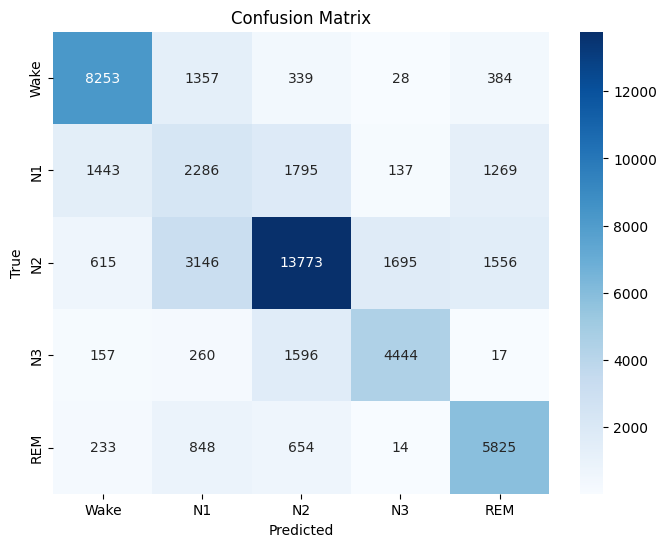

Cohen's Kappa: 0.5571


In [10]:
y_pred_proba = model_tiny.predict(val_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

y_pred_smooth = medfilt(y_pred, kernel_size=5)
acc, kappa = utils.evaluate_model(y_val_true, y_pred_smooth)

In [9]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=True,
    window_size=3,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    select_channels=[0]   # <-- doar EEG
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    select_channels=[0]   # <-- doar EEG
)

# y_val_true (cum făceai deja)
y_val_true = []
for i in range(len(val_gen)):
    _, y_batch = val_gen[i]
    y_val_true.extend(np.argmax(y_batch, axis=1))
y_val_true = np.array(y_val_true)

def categorical_focal_loss(gamma=2.0, alpha=None):
    def loss(y_true, y_pred):
   y_pred = ops.clip(y_pred, 1e-7, 1.0)
   ce = -ops.sum(y_true * ops.log(y_pred), axis=-1)
   p_t = ops.sum(y_true * y_pred, axis=-1)
   modulating = (1.0 - p_t) ** gamma

   if alpha is not None:
       alpha_t = ops.sum(y_true * ops.convert_to_tensor(alpha), axis=-1)
       fl = alpha_t * modulating * ce
        else:
            fl = modulating * ce

        return ops.mean(fl)
    return loss

alpha = [1.0, 3.0, 1.0, 1.2, 2.5]  # Wake, N1, N2, N3, REM

Epoch 1/50

Epoch 1: val_loss improved from None to 9.69409, saving model to tinysleepnet_real.keras

Epoch 1: finished saving model to tinysleepnet_real.keras
259/259 - 211s - 816ms/step - accuracy: 0.2443 - loss: 1.6917 - val_accuracy: 0.1980 - val_loss: 9.6941 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss did not improve from 9.69409
259/259 - 209s - 805ms/step - accuracy: 0.3618 - loss: 1.4162 - val_accuracy: 0.2287 - val_loss: 11.2654 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 9.69409 to 1.94579, saving model to tinysleepnet_real.keras

Epoch 3: finished saving model to tinysleepnet_real.keras
259/259 - 204s - 787ms/step - accuracy: 0.3808 - loss: 1.3797 - val_accuracy: 0.3262 - val_loss: 1.9458 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss improved from 1.94579 to 1.85012, saving model to tinysleepnet_real.keras

Epoch 4: finished saving model to tinysleepnet_real.keras
259/259 - 201s - 775ms/step - accuracy: 0.3797 - loss: 1.3838 - val_ac

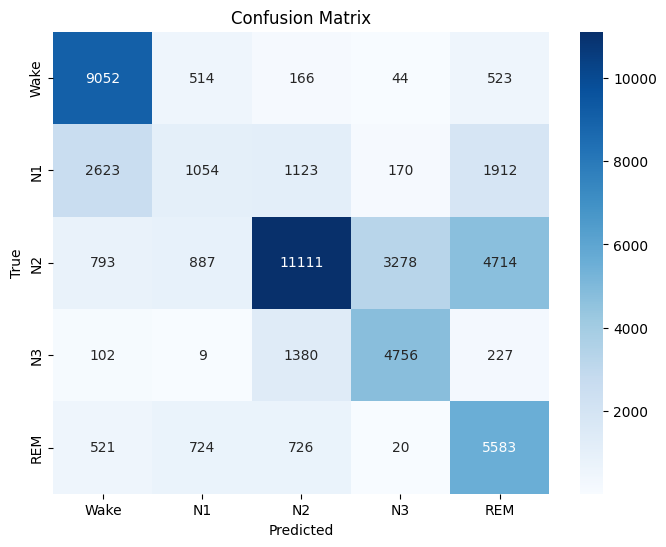

Cohen's Kappa: 0.4922


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras.ops as ops

num_classes = 5

import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models

def tiny_block(x, filters, kernel_size=11, pool_size=2, dropout=0.25):
    x = layers.SeparableConv1D(filters, kernel_size, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size)(x)
    x = layers.Dropout(dropout)(x)
    return x

inputs = layers.Input(shape=(4500, 1), name="input_eeg")

x = tiny_block(inputs, 32, 11, 2, 0.2)
x = tiny_block(x, 64, 11, 2, 0.2)
x = tiny_block(x, 128, 11, 2, 0.2)
x = tiny_block(x, 128, 11, 2, 0.2)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)

model_tiny_real = models.Model(inputs, outputs)

alpha = [1.0, 3.0, 1.0, 1.2, 2.5]

model_tiny_real.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

ckpt = tf.keras.callbacks.ModelCheckpoint(
    "tinysleepnet_real.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

history_tiny = model_tiny_real.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[lr_scheduler, es, ckpt],
    verbose=2
)

y_pred_proba_tiny = model_tiny_real.predict(val_gen)
y_pred_tiny = np.argmax(y_pred_proba_tiny, axis=1)

acc_tiny, kappa_tiny = utils.evaluate_model(y_val_true, y_pred_tiny)

Accuracy 0.6098

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.65      0.90      0.76     10299
          N1       0.50      0.03      0.06      6882
          N2       0.76      0.53      0.63     20783
          N3       0.57      0.73      0.64      6474
         REM       0.44      0.85      0.58      7574

    accuracy                           0.61     52012
   macro avg       0.58      0.61      0.53     52012
weighted avg       0.63      0.61      0.57     52012



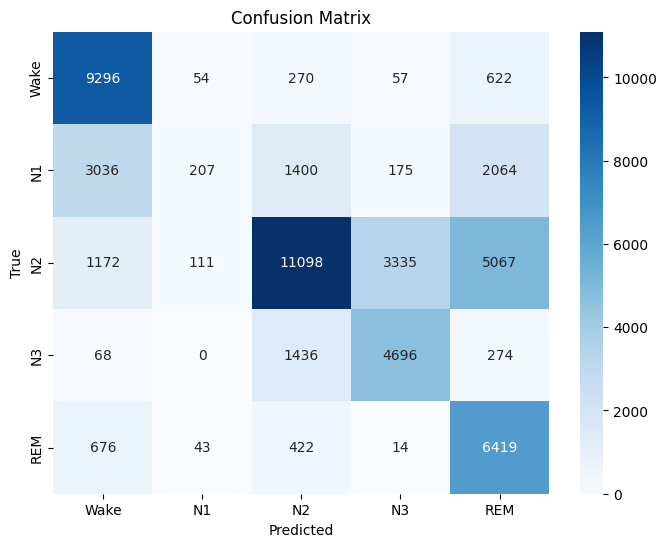

Cohen's Kappa: 0.4946


In [15]:
from scipy.ndimage import gaussian_filter1d

proba_smooth = gaussian_filter1d(y_pred_proba_tiny, sigma=1.0, axis=0)
y_pred_hmm = viterbi_decode(proba_smooth, A)

acc_tiny, kappa_tiny = utils.evaluate_model(y_val_true, y_pred_hmm)

## SeqSleepNet

In [ ]:
train_gen = utils.SleepDataGenerator(
    train_path,
    batch_size=32,
    is_training=True,
    use_context=True,
    window_size=3,
    use_lag_lead=False,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5,
    select_channels=[0]
)

val_gen = utils.SleepDataGenerator(
    val_path,
    batch_size=32,
    is_training=False,
    use_context=True,
    window_size=3,
    use_lag_lead=False,
    downsample=True,
    target_length=1500,
    sampling_rate=50,
    lag_seconds=0.5,
    select_channels=[0]
)

y_val_true = []
for i in range(len(val_gen)):
    _, y_batch = val_gen[i]
    y_val_true.extend(np.argmax(y_batch, axis=1))

y_val_true = np.array(y_val_true)

Epoch 1/50

Epoch 1: val_loss improved from None to 1.49954, saving model to seqsleepnet.keras

Epoch 1: finished saving model to seqsleepnet.keras
259/259 - 1940s - 7s/step - accuracy: 0.2358 - loss: 1.5597 - val_accuracy: 0.3193 - val_loss: 1.4995 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.49954 to 1.30110, saving model to seqsleepnet.keras

Epoch 2: finished saving model to seqsleepnet.keras
259/259 - 1384s - 5s/step - accuracy: 0.3500 - loss: 1.3977 - val_accuracy: 0.4554 - val_loss: 1.3011 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss did not improve from 1.30110
259/259 - 1378s - 5s/step - accuracy: 0.4445 - loss: 1.2984 - val_accuracy: 0.4046 - val_loss: 1.3410 - learning_rate: 0.0010
Epoch 4/50

Epoch 4: val_loss improved from 1.30110 to 1.29731, saving model to seqsleepnet.keras

Epoch 4: finished saving model to seqsleepnet.keras
259/259 - 1381s - 5s/step - accuracy: 0.4595 - loss: 1.2743 - val_accuracy: 0.4121 - val_loss: 1.2973 - learning_

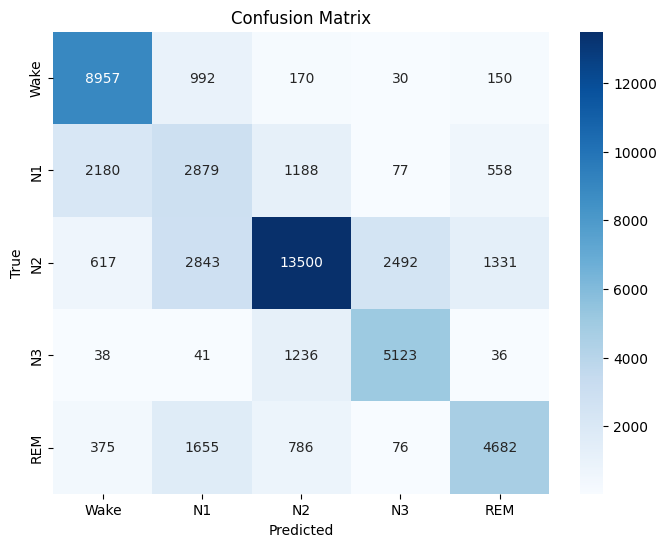

Cohen's Kappa: 0.5760


In [17]:
def frame_encoder(frame_input, frame_units=64):
    x = layers.Bidirectional(layers.GRU(frame_units, return_sequences=True))(frame_input)
    x = layers.Bidirectional(layers.GRU(frame_units))(x)
    return x

class Attention(layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, inputs):
        score = self.V(tf.nn.tanh(self.W(inputs)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * inputs, axis=1)
        return context

def build_seqsleepnet(input_length=4500, frame_length=50, frame_units=64, epoch_units=128):
    num_frames = input_length // frame_length

    inputs = layers.Input(shape=(input_length, 1))

    # reshape into frames
    x = layers.Reshape((num_frames, frame_length, 1))(inputs)

    # frame-level encoding
    x = layers.TimeDistributed(layers.Bidirectional(layers.GRU(frame_units, return_sequences=True)))(x)
    x = layers.TimeDistributed(layers.Bidirectional(layers.GRU(frame_units)))(x)

    # epoch-level encoding
    x = layers.Bidirectional(layers.GRU(epoch_units, return_sequences=True))(x)

    # attention
    x = Attention(epoch_units)(x)

    # classifier
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(5, activation="softmax")(x)

    return models.Model(inputs, outputs)

model_seq = build_seqsleepnet()

model_seq.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history_seq = model_seq.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weights,
    callbacks=[es, lr_scheduler],
    verbose=2
)

y_pred_proba = model_seq.predict(val_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

acc, kappa = utils.evaluate_model(y_val_true, y_pred)

In [ ]:
### Grid Search

In [36]:
num_classes = 5

# 1. Smoothing sets
sigma_sets = [
    [1.0],                 # simple
    [0.5, 1.0, 1.5],       # ensemble
]

def apply_smoothing(proba, sigmas):
    smoothed = [gaussian_filter1d(proba, sigma=s, axis=0, mode="nearest") for s in sigmas]
    return np.mean(smoothed, axis=0)

# 2. HMM temperature sets
temperature_sets = [
    [0.85, 0.45, 0.75, 0.95, 0.75],
    [0.80, 0.50, 0.70, 0.90, 0.70],
]

def compute_A(y, temps):
    A = np.ones((num_classes, num_classes)) * 1e-3
    for i in range(len(y) - 1):
        A[y[i], y[i+1]] += 1
    A = A / A.sum(axis=1, keepdims=True)
    for c in range(num_classes):
        A[c] = A[c] ** temps[c]
        A[c] = A[c] / A[c].sum()
    return A

# 3. Viterbi
def viterbi(proba, A):
    T, C = proba.shape
    logA = np.log(A + 1e-12)
    logP = np.log(np.clip(proba, 1e-8, 1.0))

    delta = np.zeros((T, C))
    psi = np.zeros((T, C), dtype=int)

    delta[0] = logP[0]

    for t in range(1, T):
        scores = delta[t-1][:, None] + logA
        psi[t] = np.argmax(scores, axis=0)
        delta[t] = np.max(scores, axis=0) + logP[t]

    states = np.zeros(T, dtype=int)
    states[-1] = np.argmax(delta[-1])
    for t in range(T - 2, -1, -1):
        states[t] = psi[t+1, states[t+1]]

    return states

# 4. Median filter sets 
median_sets = [
    {0:5, 1:3, 2:5, 3:9, 4:5},
    {0:5, 1:5, 2:7, 3:9, 4:5},
]

def safe_medfilt(seq, center, k):
    half = k // 2
    start = max(0, center - half)
    end = min(len(seq), center + half + 1)
    window = seq[start:end]
    if len(window) < k:
        k = len(window) if len(window) % 2 == 1 else len(window) - 1
        if k < 1:
            return seq[center]
    return medfilt(window, kernel_size=k)[len(window)//2]

def adaptive_median(seq, kernels):
    out = seq.copy()
    for i in range(len(seq)):
        out[i] = safe_medfilt(seq, i, kernels[seq[i]])
    return out

# 5. Physiologic rule sets (2 variante)
def rules_v2(seq):
    out = seq.copy()
    for i in range(1, len(seq)-1):
        prev, cur, nxt = seq[i-1], seq[i], seq[i+1]
        if prev == 1 and cur == 3 and nxt == 1:
            out[i] = 2
        if prev == 4 and cur == 2 and nxt == 4:
            out[i] = 4
    return out

def rules_v3(seq):
    out = seq.copy()
    for i in range(1, len(seq)-1):
        prev, cur, nxt = seq[i-1], seq[i], seq[i+1]
        if prev == 1 and cur == 3 and nxt == 1:
            out[i] = 2
        if prev == 4 and cur == 2 and nxt == 4:
            out[i] = 4
        if prev == 3 and cur == 0 and nxt == 3:
            out[i] = 2
    return out

rule_sets = [rules_v2, rules_v3]

# 6. Ensemble alpha
alphas = [0.7, 1.0]

def ensemble(hmm, smooth, alpha):
    return np.clip(np.round(alpha * hmm + (1 - alpha) * smooth).astype(int), 0, num_classes - 1)


In [37]:
best_acc = -1
best_combo = None
best_pred = None

for sigmas in sigma_sets:
    proba_s = apply_smoothing(y_pred_proba, sigmas)
    y_smooth = np.argmax(proba_s, axis=1)

    for temps in temperature_sets:
        A = compute_A(y_val_true, temps)
        y_hmm = viterbi(proba_s, A)

        for kernels in median_sets:
            y_med = adaptive_median(y_hmm, kernels)

            for rules in rule_sets:
                y_rules = rules(y_med)

                for alpha in alphas:
                    y_final = ensemble(y_rules, y_smooth, alpha)

                    acc = np.mean(y_final == y_val_true)
                    kappa = cohen_kappa_score(y_val_true, y_final)

                    print(f"sigmas={sigmas}, temps={temps}, kernels={kernels}, rules={rules.__name__}, alpha={alpha} \nacc={acc:.4f}, kappa={kappa:.4f}\n")

                    if acc > best_acc:
                        best_acc = acc
                        best_combo = (sigmas, temps, kernels, rules.__name__, alpha)
                        best_pred = y_final

print("\n=== BEST COMBINATION ===")
print("Accuracy:", best_acc)
print("Best params:", best_combo)

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v2, alpha=0.7 
acc=0.6801, kappa=0.5744

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v2, alpha=1.0 
acc=0.7051, kappa=0.6062

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v3, alpha=0.7 
acc=0.6801, kappa=0.5744

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 3, 2: 5, 3: 9, 4: 5}, rules=rules_v3, alpha=1.0 
acc=0.7051, kappa=0.6062

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 5, 2: 7, 3: 9, 4: 5}, rules=rules_v2, alpha=0.7 
acc=0.6802, kappa=0.5744

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 5, 2: 7, 3: 9, 4: 5}, rules=rules_v2, alpha=1.0 
acc=0.7052, kappa=0.6062

sigmas=[1.0], temps=[0.85, 0.45, 0.75, 0.95, 0.75], kernels={0: 5, 1: 5, 2: 7, 3: 9, 4: 5}, rules=rules_v3, alpha=0.7 
acc=0.6802,

In [ ]:
### Best Results

Accuracy 0.7056

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.68      0.90      0.78     10299
          N1       0.42      0.16      0.23      6882
          N2       0.78      0.73      0.75     20783
          N3       0.66      0.80      0.72      6474
         REM       0.71      0.78      0.74      7574

    accuracy                           0.71     52012
   macro avg       0.65      0.67      0.65     52012
weighted avg       0.69      0.71      0.68     52012



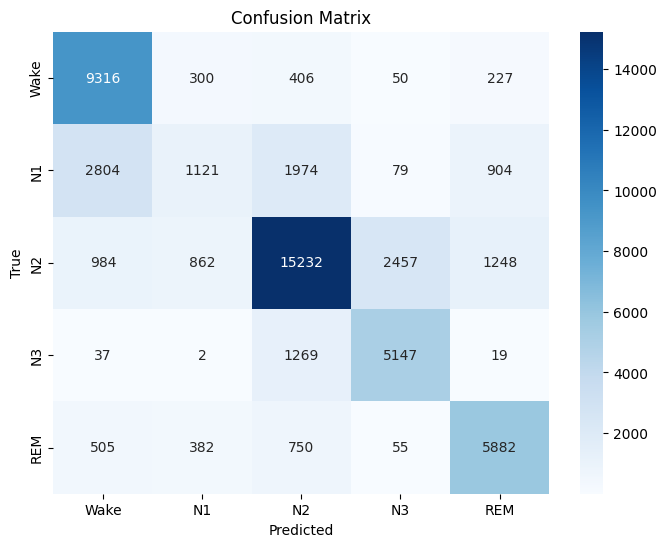

Cohen's Kappa: 0.6067


In [35]:
num_classes = 5
CLASSES = ["Wake", "N1", "N2", "N3", "REM"]

# 1. Multi-sigma Gaussian smoothing
sigma_list = [0.5, 1.0, 1.5]

probas_smooth = [
    gaussian_filter1d(y_pred_proba, sigma=s, axis=0, mode="nearest")
    for s in sigma_list
]

proba_smooth = np.mean(probas_smooth, axis=0)
y_pred_smooth = np.argmax(proba_smooth, axis=1)

# 2. HMM with class-wise adaptive temperatures
def compute_transition_matrix_adaptive(y, temps):
    A = np.ones((num_classes, num_classes)) * 1e-3
    for i in range(len(y) - 1):
        A[y[i], y[i+1]] += 1

    A = A / A.sum(axis=1, keepdims=True)

    # Temperatures per clas
    for c in range(num_classes):
        A[c] = A[c] ** temps[c]
        A[c] = A[c] / A[c].sum()

    return A

temps = [0.85, 0.45, 0.75, 0.95, 0.75]
A = compute_transition_matrix_adaptive(y_val_true, temps)

# 3. Viterbi decoding
y_hmm = viterbi(proba_smooth, A)

# 4. Median filter
def safe_medfilt(seq, center, k):
    half = k // 2
    start = max(0, center - half)
    end = min(len(seq), center + half + 1)
    window = seq[start:end]
    if len(window) < k:
        k = len(window) if len(window) % 2 == 1 else len(window) - 1
        if k < 1:
            return seq[center]
    return medfilt(window, kernel_size=k)[len(window)//2]

def adaptive_median(seq):
    out = seq.copy()
    for i in range(len(seq)):
        c = seq[i]
        if c == 1:      # N1
            out[i] = safe_medfilt(seq, i, 3)
        elif c == 2:    # N2
            out[i] = safe_medfilt(seq, i, 5)
        elif c == 3:    # N3
            out[i] = safe_medfilt(seq, i, 9)
        elif c == 4:    # REM
            out[i] = safe_medfilt(seq, i, 5)
        else:           # Wake
            out[i] = safe_medfilt(seq, i, 5)
    return out

y_med = adaptive_median(y_hmm)

def physiologic_rules(seq):
    out = seq.copy()
    for i in range(1, len(seq)-1):
        prev, cur, nxt = seq[i-1], seq[i], seq[i+1]

        # N1 → N3 → N1 => N3 devine N2
        if prev == 1 and cur == 3 and nxt == 1:
            out[i] = 2

        # REM → N2 → REM => N2 devine REM
        if prev == 4 and cur == 2 and nxt == 4:
            out[i] = 4

        # N1 → N3 direct => N1 devine N2
        if prev == 1 and nxt == 3 and cur == 1:
            out[i] = 2

        # N3 → Wake → N3 => Wake devine N2
        if prev == 3 and cur == 0 and nxt == 3:
            out[i] = 2

    return out

y_final = physiologic_rules(y_med)

acc, kappa = utils.evaluate_model(y_val_true, y_final)